# Yulu Bikes — Hypothesis Testing Case Study

## Business Case: Demand Analysis for Shared Electric Cycles in India

**Platform:** Scaler Academy
**Topic:** Hypothesis Testing

---

### About Yulu
Yulu is India's leading micro-mobility service provider offering shared electric cycles for daily commutes. They have recently suffered considerable dips in revenue and want to understand the factors driving demand for their shared electric cycles in the Indian market.

---

### Objective
- Identify which variables are **significant in predicting demand**
- Understand **how well** those variables describe electric cycle demand

---

### Statistical Methods Used
- Bi-Variate Analysis
- 2-Sample T-Test
- One-Way ANOVA
- Chi-Square Test

## Problem Definition

Yulu has suffered considerable revenue dips and wants to
identify which variables significantly affect the demand
for shared electric cycles in the Indian market.

**Dependent Variable:** count (total cycle rentals)

**Independent Variables:** season, weather, workingday,
temp, humidity, windspeed

**Goal:** Use statistical hypothesis testing to determine
which factors have a significant effect on demand and
how well those variables describe electric cycle demand.

## Step 1: Importing the Required Libraries

Before we begin our analysis, we import all the necessary Python libraries:

- **numpy** – for numerical computations
- **pandas** – for data manipulation and analysis
- **matplotlib** – for creating base visualizations
- **seaborn** – for statistical visualizations
- **scipy** – for statistical tests (T-Test, ANOVA, Chi-Square)

In [3]:
# Importing the required libraries

import numpy as np                  # numerical computations
import pandas as pd                 # data manipulation and analysis
import matplotlib.pyplot as plt     # base plotting library
import seaborn as sns               # statistical visualizations
from scipy import stats             # statistical tests (t-test, ANOVA, chi-square)

import warnings
warnings.filterwarnings('ignore')   # suppress unnecessary warnings

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Loading the Dataset

We load the Yulu bike sharing dataset using pandas `read_csv()`.
The dataset is stored in the `data/` folder of our project.

**About the Dataset:**
- Source: Yulu Bikes — Indian micro-mobility provider
- Each row represents **one hour** of bike rental data
- Target variable (what we want to predict): `count`

In [4]:
# Loading the dataset
df = pd.read_csv('bike_sharing.csv')
print("the dataframe has been imported successfully!")
print(df.head(5))


the dataframe has been imported successfully!
              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  


In [5]:
# Shape of the dataset
print("Shape",df.shape)

Shape (10886, 12)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [7]:
print("Describe",df.describe())

Describe              season       holiday    workingday       weather         temp  \
count  10886.000000  10886.000000  10886.000000  10886.000000  10886.00000   
mean       2.506614      0.028569      0.680875      1.418427     20.23086   
std        1.116174      0.166599      0.466159      0.633839      7.79159   
min        1.000000      0.000000      0.000000      1.000000      0.82000   
25%        2.000000      0.000000      0.000000      1.000000     13.94000   
50%        3.000000      0.000000      1.000000      1.000000     20.50000   
75%        4.000000      0.000000      1.000000      2.000000     26.24000   
max        4.000000      1.000000      1.000000      4.000000     41.00000   

              atemp      humidity     windspeed        casual    registered  \
count  10886.000000  10886.000000  10886.000000  10886.000000  10886.000000   
mean      23.655084     61.886460     12.799395     36.021955    155.552177   
std        8.474601     19.245033      8.164537    

## Step 3: Understanding the Dataset

We explore the dataset using three key functions:

- `df.shape` – tells us the number of rows and columns
- `df.info()` – shows column names, data types, and null value counts
- `df.describe()` – gives statistical summary (mean, std, min, max, quartiles)

### Key Observations:

**Shape:**
- 10,886 rows and 12 columns (features)

**Data Types (from df.info()):**
- 1 String → `datetime` (needs to be converted to datetime type)
- 3 Floats → `temp`, `atemp`, `windspeed` (continuous decimal values)
- 8 Integers → `season`, `holiday`, `workingday`, `weather`, `humidity`, `casual`, `registered`, `count`

**Important Issue Spotted:**
- `season`, `weather`, `holiday`, `workingday` are stored as integers
  but they actually represent **categories**, not numbers
- Season 4 (Winter) is NOT greater than Season 1 (Spring) — they are just labels
- These must be converted to `category` type before analysis

**From df.describe():**
- `count` (our target) has a mean of **191.57** but std of **181.14**
  — this large standard deviation tells us demand is **highly variable**
- `atemp` = apparent/feels-like temperature (different from actual `temp`)
- Averaging `season` or `weather` is meaningless — confirms need for type conversion

In [8]:
# Converting datetime column from string to proper datetime type
df['datetime'] = pd.to_datetime(df['datetime'])

# Converting categorical columns from int64 to category type
# Reason: season, weather, holiday, workingday are labels not numbers
cat_cols = ['season', 'weather', 'holiday', 'workingday']
for col in cat_cols:
    df[col] = df[col].astype('category')

# Verify the changes
print("Updated Data Types:")
print(df.dtypes)

Updated Data Types:
datetime      datetime64[us]
season              category
holiday             category
workingday          category
weather             category
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dtype: object


## Step 4: Data Preprocessing

Before analysis, we fix two data type issues:

**1. datetime column:**
- Was stored as a plain string
- Converted to `datetime64` using `pd.to_datetime()`

**2. Categorical columns:**
- `season`, `weather`, `holiday`, `workingday` were stored as integers
- Converted to `category` type using `.astype('category')`
- Reason: these are labels, not numbers — Season 4 is not
  mathematically greater than Season 1

In [9]:
# Missing Values in the Dataset
df.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [10]:
# Duplicate Data
df.duplicated().sum()

np.int64(0)

## Step 5: Missing Values & Duplicate Check

### Missing Values:
- Checked using `df.isnull().sum()`
- **Result: 0 missing values** across all 12 columns
- No imputation or row removal needed

### Duplicate Rows:
- Checked using `df.duplicated().sum()`
- **Result: 0 duplicate rows** found
- Dataset is clean and ready for analysis

In [11]:
# Skewness & Kurtosis for all continuous variables
# Skewness: measures how lopsided the distribution is
# Kurtosis: measures how heavy the tails are (outlier presence)

continuous_cols = ['temp', 'atemp', 'humidity', 'windspeed',
                   'casual', 'registered', 'count']

print("=" * 55)
print(f"{'Column':<12} {'Skewness':>10}  {'Kurtosis':>10}")
print("=" * 55)
for col in continuous_cols:
    skew = df[col].skew()
    kurt = df[col].kurt()
    print(f"{col:<12} {skew:>10.2f}  {kurt:>10.2f}")
print("=" * 55)

Column         Skewness    Kurtosis
temp               0.00       -0.91
atemp             -0.10       -0.85
humidity          -0.09       -0.76
windspeed          0.59        0.63
casual             2.50        7.55
registered         1.52        2.63
count              1.24        1.30


## Step 6: Skewness & Kurtosis Analysis

Skewness and Kurtosis help us understand the shape of
each continuous variable's distribution.

**Skewness Rules:**
- Between -1 and +1 → Normal ✅
- Between +1 and +2 → Moderate right skew ⚠️
- Greater than +2   → Highly skewed ❌

**Kurtosis Rules:**
- Around 0          → Normal ✅
- Greater than +3   → Heavy tails / many outliers ❌
- Less than -1      → Light tails / few outliers ⚠️

**Key Findings:**
- `temp`, `atemp`, `humidity` → Nearly normal, reliable variables
- `windspeed` → Slight right skew, acceptable
- `casual` → Highly right skewed (2.50) with heavy tails (7.55)
  → Most hours have few casual riders but occasional huge spikes
- `registered` and `count` → Moderate right skew
  → Demand is mostly low but has high-demand outlier events

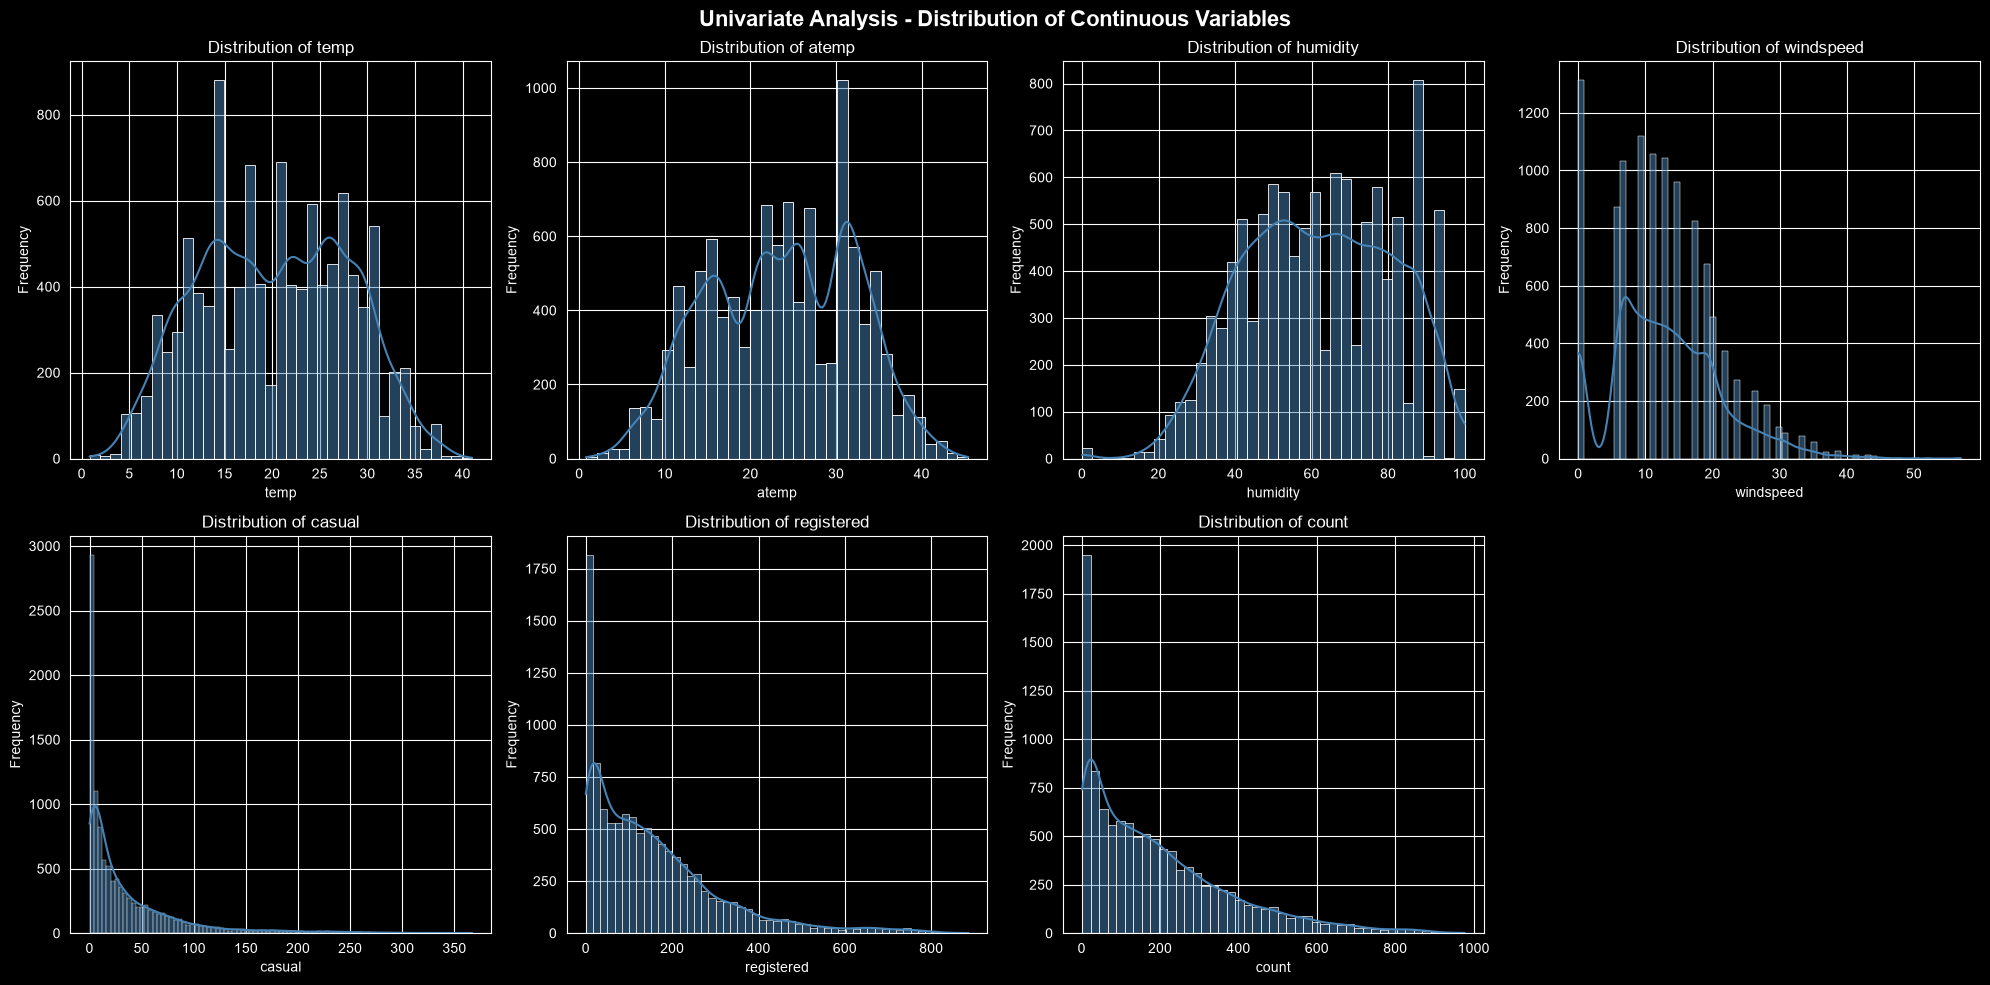

In [12]:
# Distribution plots for all continuous variables
continuous_cols = ['temp', 'atemp', 'humidity', 'windspeed',
                   'casual', 'registered', 'count']

# Create a 2x4 grid of plots (7 variables + 1 empty)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Flatten from 2D grid to 1D list so we can loop easily
axes = axes.flatten()

# Loop through each column and plot
for i, col in enumerate(continuous_cols):
    sns.histplot(df[col], ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide the 8th empty subplot
axes[7].set_visible(False)

plt.suptitle('Univariate Analysis - Distribution of Continuous Variables',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Univariate Analysis - Distribution Plots

Histograms with KDE curves plotted for all 7 continuous variables.

### Observations:

**temp:**
- Bimodal distribution (two peaks) — two common temperature ranges
- Roughly symmetric overall, skewness = 0.00

**atemp:**
- Closely follows a normal distribution
- Slight left skew (-0.10) but largely balanced

**humidity:**
- Most data concentrated between 60-100
- Very mild left skew (-0.09) with small tail towards lower values

**windspeed:**
- Right skewed (0.59) — most hours have low wind
- Long tail towards higher wind speeds

**casual:**
- Heavily right skewed (2.50) — worst of all variables
- Most hours have very few casual riders
- Occasional massive spikes create a long right tail

**registered:**
- Moderately right skewed (1.52)
- More evenly spread than casual but still lopsided

**count:**
- Moderately right skewed (1.24)
- Reflects combined casual + registered pattern
- Most hours have low-to-medium demand

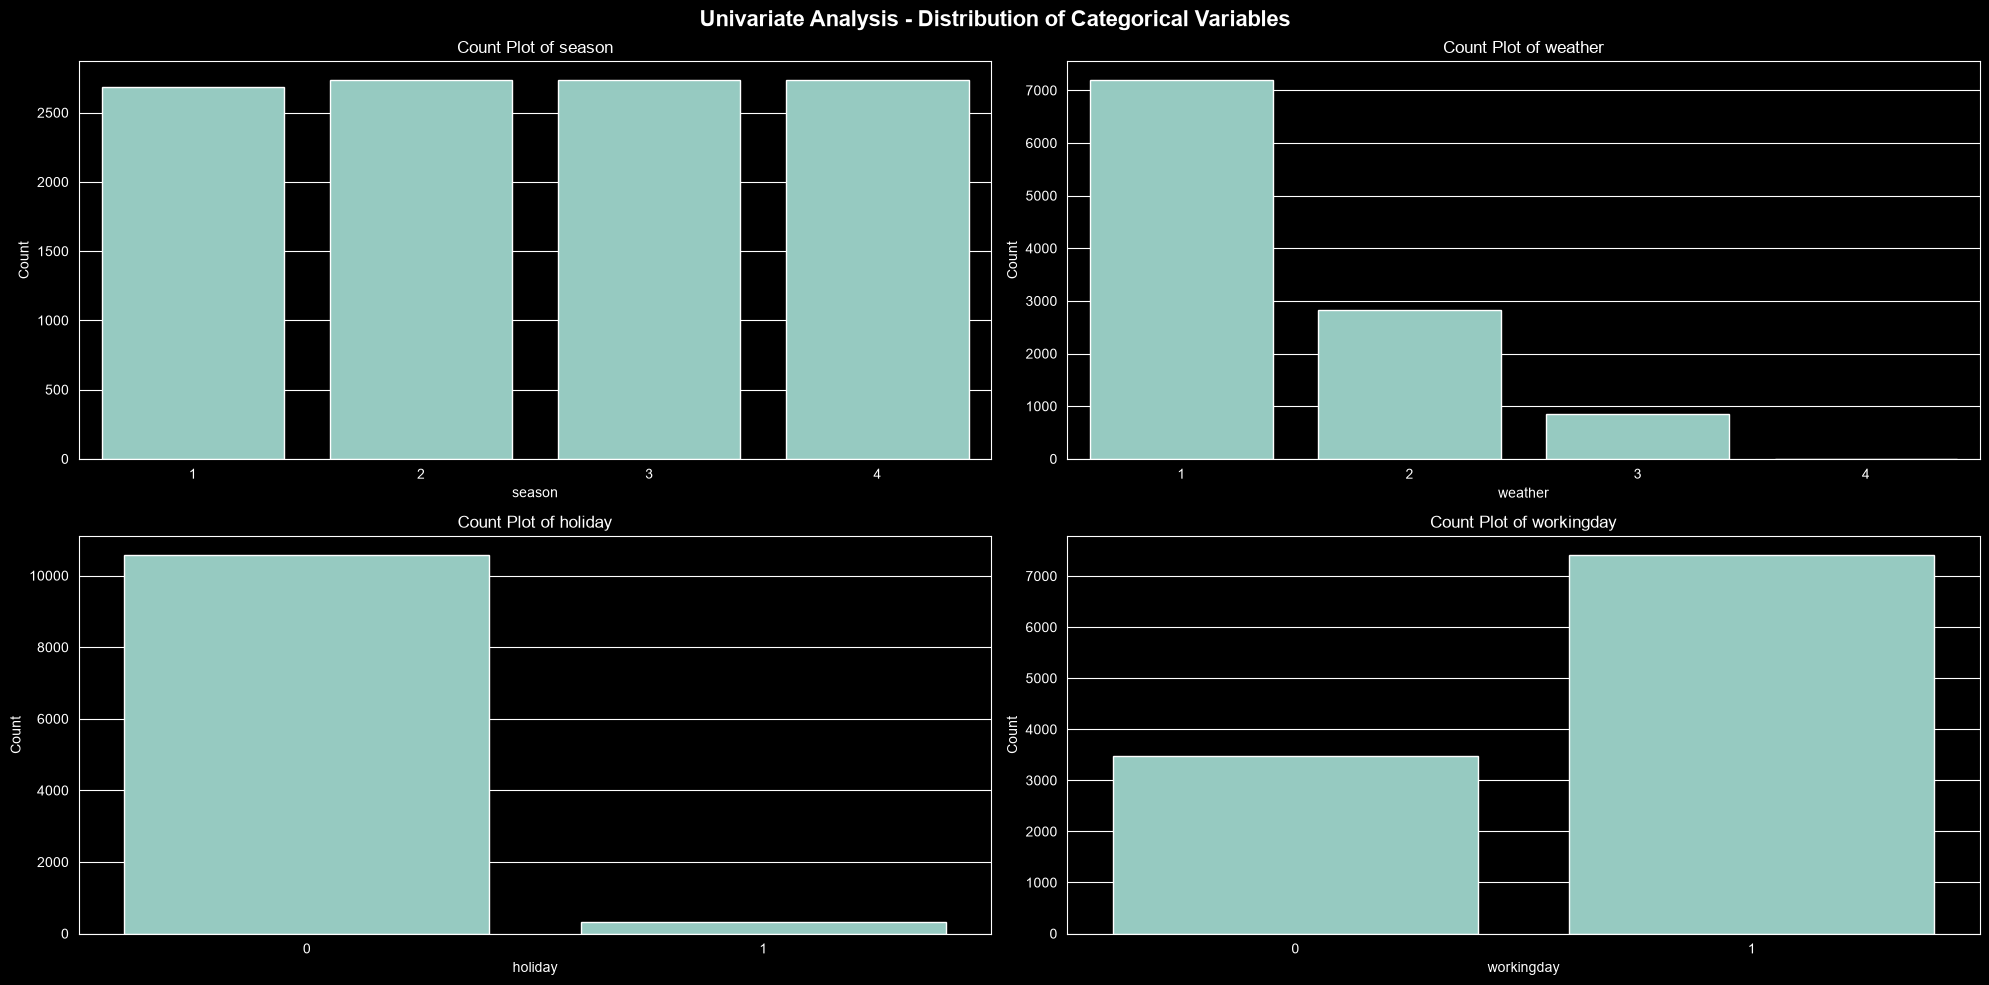

In [13]:
# Distribution plots for all categorical variables
categorical_cols = ['season', 'weather', 'holiday', 'workingday']

# Create a 2x2 grid of plots (4 variables)
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

# Flatten from 2D grid to 1D list so we can loop easily
axes = axes.flatten()

# Loop through each column and plot
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Univariate Analysis - Distribution of Categorical Variables',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8: Univariate Analysis - Categorical Variables (Count Plots)

Count plots showing frequency of each category for all 4 categorical variables.

**Season (1=Spring, 2=Summer, 3=Fall, 4=Winter):**
- Spring has the lowest rental count
- Summer, Fall and Winter are roughly equal
- Spring likely suffers from unpredictable weather and lower temperatures

**Weather (1=Clear, 2=Mist, 3=Light Rain, 4=Heavy Rain):**
- Clear weather (1) dominates overwhelmingly
- Heavy Rain (4) has almost no observations
- People strongly prefer riding in good weather conditions

**Holiday (0=No, 1=Yes):**
- Non-holidays have significantly more rentals than holidays
- Dataset is heavily imbalanced — very few holiday records exist
- Suggests bikes are used more for daily commuting than leisure

**Workingday (0=No, 1=Yes):**
- Working days show higher rental counts
- Confirms bikes are primarily used as a commuting tool
- Non-working days (weekends) show lower but still significant usage

**Key Business Insight:**
- Weather and workingday are the strongest visible influencers of demand
- Season should NOT be dismissed — it will be formally tested with ANOVA
- Holiday imbalance should be kept in mind during hypothesis testing

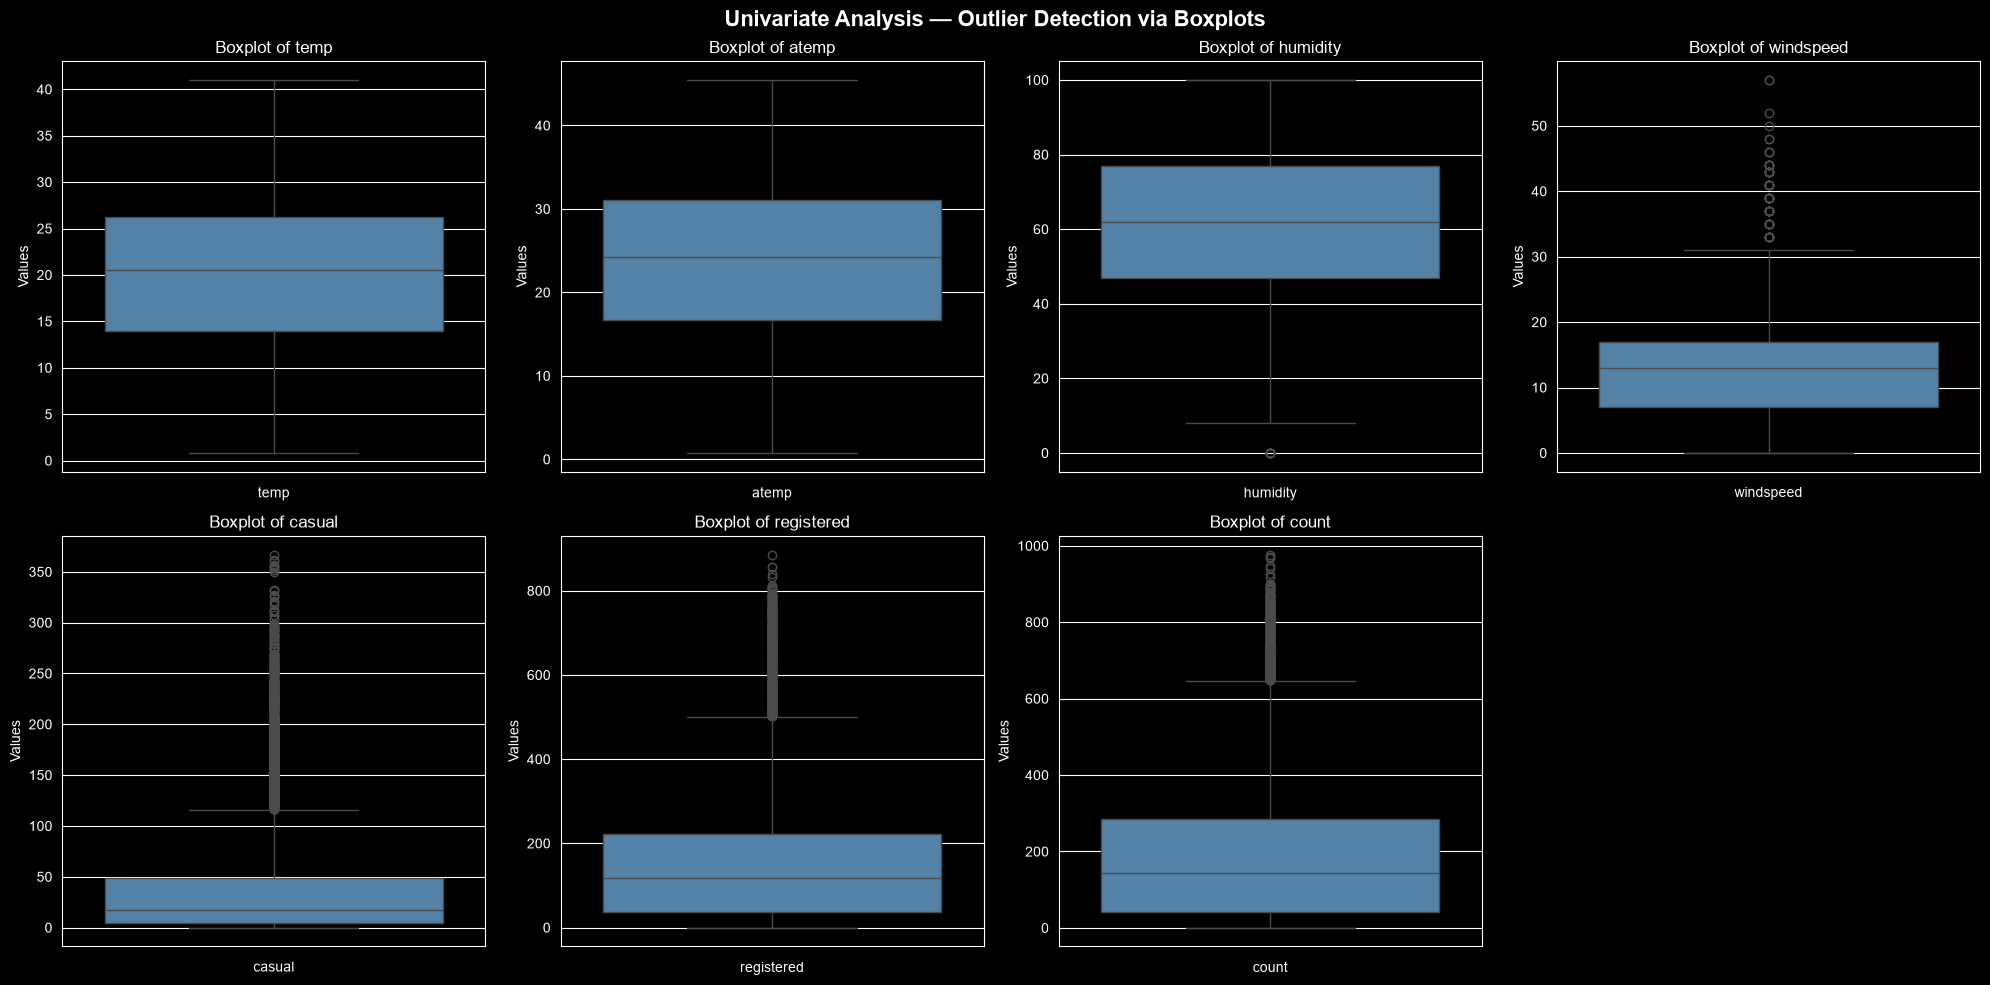

In [14]:
# Boxplots for outlier detection
box_continuous_cols = ['temp', 'atemp', 'humidity', 'windspeed',
                       'casual', 'registered', 'count']

# Create a 2x4 grid (7 variables + 1 empty slot)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Flatten from 2D grid to 1D list for easy looping
axes = axes.flatten()

# Plot a boxplot for each continuous variable
for i, col in enumerate(box_continuous_cols):
    sns.boxplot(y=col, data=df, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Values')

# Hide the unused 8th subplot
axes[7].set_visible(False)

plt.suptitle('Univariate Analysis — Outlier Detection via Boxplots',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 9: Univariate Analysis — Outlier Detection via Boxplots

Boxplots show the spread of data and highlight outliers beyond 1.5 × IQR.

**How to read a boxplot:**
- Box = middle 50% of data (Q1 to Q3)
- Line inside box = median
- Whiskers = 1.5 × IQR from Q1 and Q3
- Dots beyond whiskers = outliers

**Observations by variable:**

| Variable | Outliers | Severity |
|----------|----------|----------|
| casual | Many dots above whisker | ❌ Extreme |
| registered | Several dots above whisker | ❌ Heavy |
| count | Moderate dots above whisker | ⚠️ Moderate |
| windspeed | Few dots above whisker | ⚠️ Mild |
| humidity | One dot below whisker | ✅ Minimal |
| temp | No outliers | ✅ Clean |
| atemp | No outliers | ✅ Clean |

**Key Business Insight:**
- Outliers in casual, registered and count are NOT data errors
- They represent genuine peak demand events — festivals, holidays,
  perfect weather days
- These outliers will be retained as they reflect real business scenarios
- casual shows the most extreme behaviour confirming its high skewness
  of 2.50 from our earlier analysis

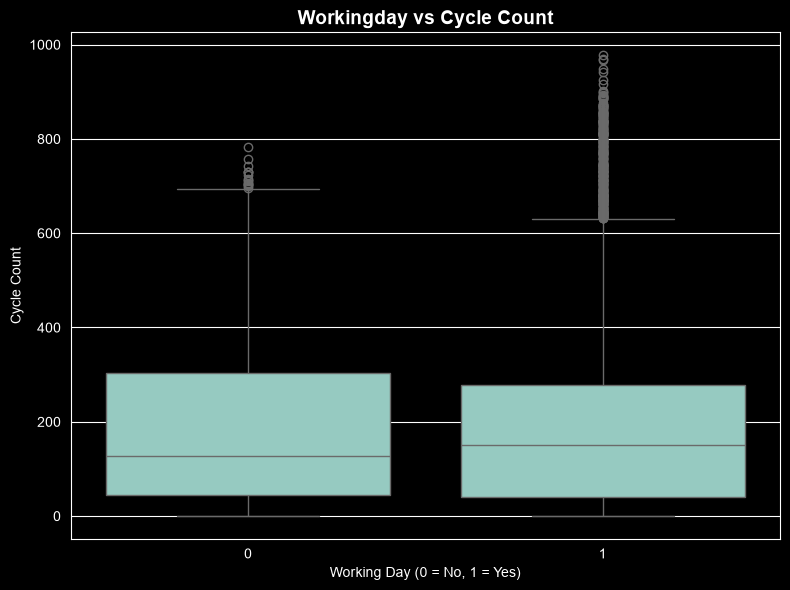

In [15]:
# Bivariate Analysis: Workingday vs Count
plt.figure(figsize=(8, 6))

sns.boxplot(x='workingday', y='count', data=df)

plt.title('Workingday vs Cycle Count', fontsize=14, fontweight='bold')
plt.xlabel('Working Day (0 = No, 1 = Yes)')
plt.ylabel('Cycle Count')

plt.tight_layout()
plt.show()

## Step 10: Bivariate Analysis — Workingday vs Count

Comparing cycle rental count across working and non-working days.

**Observations:**
- Working day (1) has a higher median count than non-working day (0)
- Non-working day (0) has a larger IQR — more spread in demand
- Working day (1) has more extreme outliers at the top
- The two boxes sit at visually different levels

**Preliminary Conclusion:**
- Working day appears to influence cycle demand
- However this cannot be confirmed visually alone
- A 2-Sample T-Test will statistically verify this finding

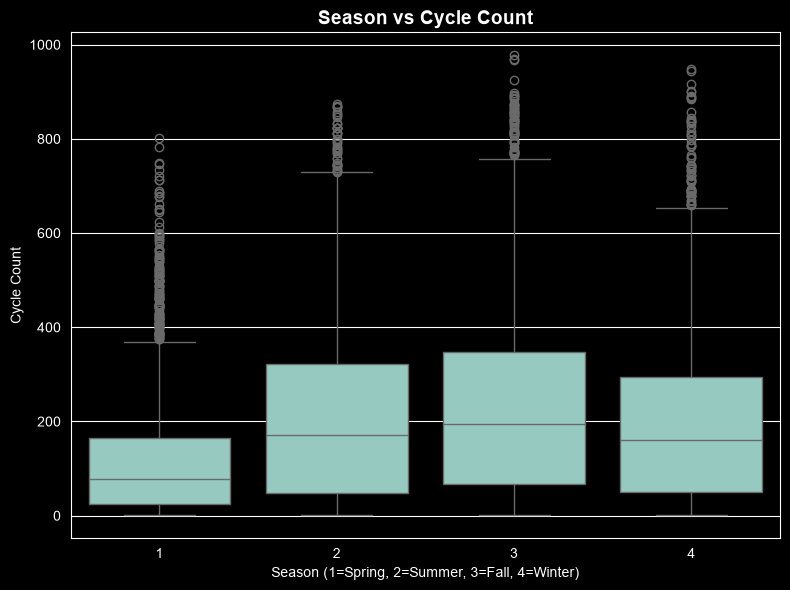

In [16]:
# Bivariate Analysis: Season vs Count
plt.figure(figsize=(8, 6))

sns.boxplot(x='season', y='count', data=df)

plt.title('Season vs Cycle Count', fontsize=14, fontweight='bold')
plt.xlabel('Season (1=Spring, 2=Summer, 3=Fall, 4=Winter)')
plt.ylabel('Cycle Count')

plt.tight_layout()
plt.show()

## Step 11: Bivariate Analysis — Season vs Count

Comparing cycle rental count across all four seasons.

**Observations:**
- Spring (1) has the lowest median count — coldest, most unpredictable weather
- Fall (3) has the highest median count — most comfortable riding conditions
- Summer (2) is close to Fall but slightly lower
- Winter (4) sits between Spring and Summer
- Fall has the most outliers — peak demand events more common
- All 4 boxes sit at visually different levels

**Preliminary Conclusion:**
- Season clearly appears to influence cycle demand
- The differences between seasons look significant visually
- A One-Way ANOVA will statistically confirm this finding

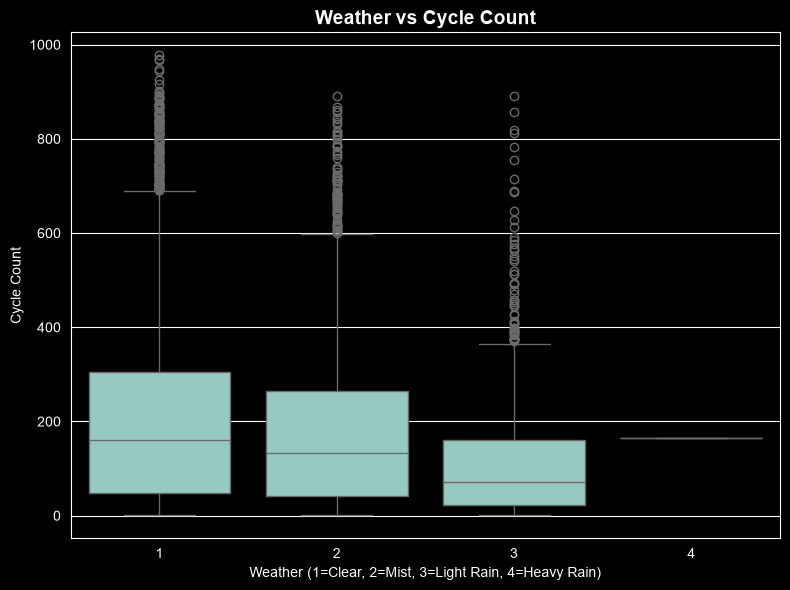

In [17]:
# Bivariate Analysis: Weather vs Count
plt.figure(figsize=(8, 6))

sns.boxplot(x='weather', y='count', data=df)

plt.title('Weather vs Cycle Count', fontsize=14, fontweight='bold')
plt.xlabel('Weather (1=Clear, 2=Mist, 3=Light Rain, 4=Heavy Rain)')
plt.ylabel('Cycle Count')

plt.tight_layout()
plt.show()

## Step 12: Bivariate Analysis — Weather vs Count

Comparing cycle rental count across all weather conditions.

**Observations:**
- Clear weather (1) has the highest median count and widest spread
- Mist/Cloudy (2) has slightly lower demand than Clear but still healthy
- Light Rain (3) shows a noticeable drop in demand
- Heavy Rain (4) shows an almost flat boxplot — Q1 ≈ Median ≈ Q3

**Key Insight on Weather 4 (Heavy Rain):**
- The flat boxplot is NOT because demand is perfectly consistent
- It is because extremely few records exist for Heavy Rain
- Almost nobody rents bikes in Heavy Rain conditions
- No outliers visible because there is barely enough data to show spread

**Preliminary Conclusion:**
- Weather has a clear and strong effect on cycle demand
- Demand drops consistently as weather worsens
- A One-Way ANOVA will statistically confirm this finding

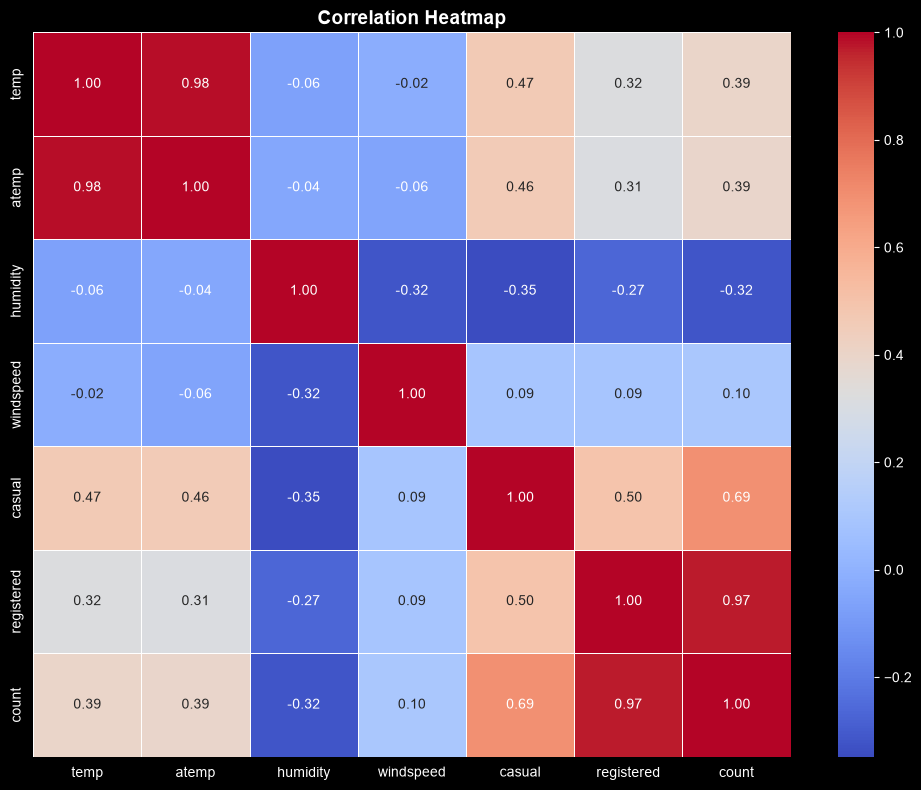

In [18]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))

# Calculate correlation between all numeric columns
correlation = df.corr(numeric_only=True)

# Plot the heatmap
sns.heatmap(correlation,
            annot=True,        # show numbers inside each cell
            fmt='.2f',         # round to 2 decimal places
            cmap='coolwarm',   # red=positive, blue=negative correlation
            linewidths=0.5)    # thin lines between cells

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 13: Bivariate Analysis — Correlation Heatmap

Heatmap showing correlation between all continuous variables.

**Reading the heatmap:**
- Values close to +1 = strong positive correlation (red)
- Values close to -1 = strong negative correlation (blue)
- Values close to 0  = no relationship (white)

**Key findings (focusing on count row):**

| Variable | Correlation with Count | Interpretation |
|----------|----------------------|----------------|
| registered | 0.97 | Very strong positive |
| casual | 0.69 | Strong positive |
| temp | 0.39 | Moderate positive |
| atemp | 0.39 | Moderate positive |
| windspeed | 0.10 | Very weak positive |
| humidity | -0.32 | Moderate negative |

**Notable observations:**
- registered vs count = 0.97 → expected since count = casual + registered
- casual vs count = 0.69 → strong relationship
- temp vs atemp = 0.98 → near perfect correlation (multicollinearity)
  → in future modelling only one should be kept
- humidity vs count = -0.32 → higher humidity means fewer rentals
  → people avoid riding in sticky, humid conditions

**Business Insight:**
- Temperature positively drives demand
- Humidity negatively drives demand
- Registered users are the backbone of Yulu's revenue

## Hypothesis Testing — Theory & Framework

---

### The Golden Rule
> If **p-value < alpha** → REJECT H0
> If **p-value > alpha** → FAIL TO REJECT H0

---

### The Criminal Analogy
- **H0 (Null Hypothesis)** = Innocent until proven guilty
- **H1 (Alternate Hypothesis)** = Guilty
- If p-value < alpha → REJECT H0 → Enough evidence to convict
- If p-value > alpha → FAIL TO REJECT H0 → Not enough evidence

---

### Alpha & Confidence Level
Confidence Level = 95% → Alpha = 0.05

Confidence Level = 99% → Alpha = 0.01

Confidence Level = 90% → Alpha = 0.10
Alpha = 1 - Confidence Level

They always add up to 100%

**For this project we use alpha = 0.05 throughout**

---

### Which Test to Use?

| Situation | Test | Memory Trick |
|-----------|------|--------------|
| Comparing 2 groups vs numerical | 2-Sample T-Test | T for Two |
| Comparing 3+ groups vs numerical | ANOVA | A for mAny |
| Categorical vs Categorical | Chi-Square | C for Categories |

---

### Our Project Tests

| Test | Question | Why This Test |
|------|----------|---------------|
| 2-Sample T-Test | Does Working Day affect Count? | 2 groups (0,1) vs numerical |
| ANOVA | Does Weather affect Count? | 4 groups vs numerical |
| ANOVA | Does Season affect Count? | 4 groups vs numerical |
| Chi-Square | Is Weather dependent on Season? | categorical vs categorical |

---

### The 7 Steps of Hypothesis Testing
Step 1 → Define H0 and H1

Step 2 → Set alpha (0.05 for this project)

Step 3 → Check assumptions

Step 4 → Run the statistical test

Step 5 → Get the p-value

Step 6 → Compare p-value with alpha

Step 7 → Make decision and interpret results

---

### Assumptions to Check

**2-Sample T-Test:**
- Normality → data should be normally distributed
- Equal Variance → both groups should have similar variance

**ANOVA:**
- Normality → each group should be normally distributed
- Equal Variance → all groups should have similar variance

**Chi-Square:**
- Expected frequency → each cell should have at least 5 observations

---

### Tests Used to Check Assumptions

| Assumption | Test | Code |
|------------|------|------|
| Normality | Shapiro-Wilk Test | `stats.shapiro()` |
| Equal Variance | Levene's Test | `stats.levene()` |

In [19]:
# 2-Sample T-Test: Working Day vs Count

# Step 1: Define Hypotheses
print("H0: Working day has NO effect on cycle count")
print("H1: Working day DOES have an effect on cycle count")
print(f"Alpha = 0.05")
print()


H0: Working day has NO effect on cycle count
H1: Working day DOES have an effect on cycle count
Alpha = 0.05



In [20]:
# Step 2: Split into two groups
working     = df[df['workingday'] == 1]['count']
non_working = df[df['workingday'] == 0]['count']

print(f"Working Day     → n={len(working)},     mean={working.mean():.2f}")
print(f"Non-Working Day → n={len(non_working)}, mean={non_working.mean():.2f}")
print()


Working Day     → n=7412,     mean=193.01
Non-Working Day → n=3474, mean=188.51



In [21]:
# Step 3: Check Normality — Shapiro-Wilk Test
stat_w,  p_w  = stats.shapiro(working)
stat_nw, p_nw = stats.shapiro(non_working)

print("=== Normality Check (Shapiro-Wilk Test) ===")
print(f"Working Day     → W={stat_w:.4f},  p={p_w:.6f}")
print(f"Non-Working Day → W={stat_nw:.4f}, p={p_nw:.6f}")
print()


=== Normality Check (Shapiro-Wilk Test) ===
Working Day     → W=0.8703,  p=0.000000
Non-Working Day → W=0.8852, p=0.000000



In [22]:
# Step 4: Check Equal Variance — Levene's Test
stat_lev, p_lev = stats.levene(working, non_working)

print("=== Equal Variance Check (Levene's Test) ===")
print(f"Levene Statistic={stat_lev:.4f}, p={p_lev:.6f}")
print()


=== Equal Variance Check (Levene's Test) ===
Levene Statistic=0.0050, p=0.943782



In [23]:
# Step 5: Run 2-Sample T-Test
t_stat, p_value = stats.ttest_ind(working, non_working)

print("=== 2-Sample T-Test Results ===")
print(f"T-Statistic = {t_stat:.4f}")
print(f"P-Value     = {p_value:.6f}")
print()


=== 2-Sample T-Test Results ===
T-Statistic = 1.2096
P-Value     = 0.226448



In [24]:
# Step 6: Decision
print("=== Decision ===")
if p_value < 0.05:
    print("p-value < 0.05 → REJECT H0")
    print("Working day DOES have a significant effect on cycle count")
else:
    print("p-value > 0.05 → FAIL TO REJECT H0")
    print("Working day does NOT have a significant effect on cycle count")

=== Decision ===
p-value > 0.05 → FAIL TO REJECT H0
Working day does NOT have a significant effect on cycle count


## Hypothesis Test 1: 2-Sample T-Test
### Does Working Day affect Cycle Count?

**Hypotheses:**
- H0: Working day has NO significant effect on cycle count
- H1: Working day DOES have a significant effect on cycle count
- Alpha = 0.05

**Assumption Checks:**

Normality (Shapiro-Wilk):
- Working Day     → p=0.000000 ❌ Normality failed
- Non-Working Day → p=0.000000 ❌ Normality failed
- However with large samples (n=7412, n=3474) Central Limit
  Theorem ensures T-Test is still valid

Equal Variance (Levene's Test):
- p = 0.943782 > 0.05 ✅ Equal variance confirmed

**T-Test Results:**
- T-Statistic = 1.2096
- P-Value     = 0.226448

**Decision:**
- p-value (0.226) > alpha (0.05)
- FAIL TO REJECT H0

**Conclusion:**
Working day does NOT have a statistically significant effect
on cycle count. Despite the visual difference in boxplots,
the difference in means (193.01 vs 188.51) is not large
enough to be statistically meaningful.

In [25]:
# ANOVA Test: Weather vs Count

# Step 1: Define Hypotheses
print("H0: Mean cycle count is the SAME across all weather conditions")
print("H1: At least one weather condition has a DIFFERENT mean count")
print("Alpha = 0.05")
print()


H0: Mean cycle count is the SAME across all weather conditions
H1: At least one weather condition has a DIFFERENT mean count
Alpha = 0.05



In [26]:
# Step 2: Split into groups
weather1 = df[df['weather'] == 1]['count']
weather2 = df[df['weather'] == 2]['count']
weather3 = df[df['weather'] == 3]['count']
weather4 = df[df['weather'] == 4]['count']

print("=== Group Statistics ===")
print(f"Clear (1)          → n={len(weather1)}, mean={weather1.mean():.2f}")
print(f"Mist (2)           → n={len(weather2)}, mean={weather2.mean():.2f}")
print(f"Light Rain (3)     → n={len(weather3)}, mean={weather3.mean():.2f}")
print(f"Heavy Rain (4)     → n={len(weather4)}, mean={weather4.mean():.2f}")
print()


=== Group Statistics ===
Clear (1)          → n=7192, mean=205.24
Mist (2)           → n=2834, mean=178.96
Light Rain (3)     → n=859, mean=118.85
Heavy Rain (4)     → n=1, mean=164.00



In [27]:
# Step 3: Check Normality — Shapiro-Wilk
print("=== Normality Check (Shapiro-Wilk) ===")
for weather, name in [(weather1,'Clear'),(weather2,'Mist'),
                       (weather3,'Light Rain'),(weather4,'Heavy Rain')]:
    stat, p = stats.shapiro(weather)
    print(f"{name:<12} → W={stat:.4f}, p={p:.6f}")
print()


=== Normality Check (Shapiro-Wilk) ===
Clear        → W=0.8909, p=0.000000
Mist         → W=0.8768, p=0.000000
Light Rain   → W=0.7674, p=0.000000
Heavy Rain   → W=nan, p=nan



In [28]:
# Step 4: Check Equal Variance — Levene's Test
stat_lev, p_lev = stats.levene(weather1, weather2, weather3, weather4)
print("=== Equal Variance Check (Levene's Test) ===")
print(f"Levene Statistic={stat_lev:.4f}, p={p_lev:.6f}")
print()


=== Equal Variance Check (Levene's Test) ===
Levene Statistic=54.8511, p=0.000000



In [29]:
# Step 5: Run One-Way ANOVA
f_stat, p_value = stats.f_oneway(weather1, weather2, weather3, weather4)
print("=== ANOVA Results ===")
print(f"F-Statistic = {f_stat:.4f}")
print(f"P-Value     = {p_value:.6f}")
print()


=== ANOVA Results ===
F-Statistic = 65.5302
P-Value     = 0.000000



In [30]:
# Step 6: Decision
print("=== Decision ===")
if p_value < 0.05:
    print("p-value < 0.05 → REJECT H0")
    print("Weather DOES have a significant effect on cycle count")
else:
    print("p-value > 0.05 → FAIL TO REJECT H0")
    print("Weather does NOT have a significant effect on cycle count")

=== Decision ===
p-value < 0.05 → REJECT H0
Weather DOES have a significant effect on cycle count


## Hypothesis Test 2: One-Way ANOVA
### Does Weather affect Cycle Count?

**Hypotheses:**
- H0: Mean cycle count is the SAME across all weather conditions
- H1: At least one weather condition has a DIFFERENT mean count
- Alpha = 0.05

**Group Statistics:**
| Weather | n | Mean Count |
|---------|---|------------|
| Clear (1) | 7192 | 205.24 |
| Mist (2) | 2834 | 178.96 |
| Light Rain (3) | 859 | 118.85 |
| Heavy Rain (4) | 1 | 164.00 |

**Assumption Checks:**

Normality (Shapiro-Wilk):
- All groups failed normality ❌
- Heavy Rain shows nan — only 1 record exists
- Central Limit Theorem applied for large groups

Equal Variance (Levene's Test):
- p = 0.000000 ❌ Equal variance failed
- We proceed as instructed by the assignment

**ANOVA Results:**
- F-Statistic = 65.5302
- P-Value     = 0.000000

**Decision:**
- p-value (0.000) < alpha (0.05)
- REJECT H0 ✅

**Conclusion:**
Weather DOES have a statistically significant effect on
cycle count. As weather worsens, demand drops consistently.
Clear weather drives the highest demand (mean=205.24) while
Light Rain shows a dramatic drop (mean=118.85).
This confirms our earlier visual observations from the boxplot.

In [31]:
# ANOVA Test: Season vs Count

# Step 1: Define Hypotheses
print("H0: Mean cycle count is the SAME across all seasons")
print("H1: At least one season has a DIFFERENT mean cycle count")
print("Alpha = 0.05")
print()


H0: Mean cycle count is the SAME across all seasons
H1: At least one season has a DIFFERENT mean cycle count
Alpha = 0.05



In [32]:
# Step 2: Split into groups
season1 = df[df['season'] == 1]['count']  # Spring
season2 = df[df['season'] == 2]['count']  # Summer
season3 = df[df['season'] == 3]['count']  # Fall
season4 = df[df['season'] == 4]['count']  # Winter

print("=== Group Statistics ===")
print(f"Spring (1) → n={len(season1)}, mean={season1.mean():.2f}")
print(f"Summer (2) → n={len(season2)}, mean={season2.mean():.2f}")
print(f"Fall   (3) → n={len(season3)}, mean={season3.mean():.2f}")
print(f"Winter (4) → n={len(season4)}, mean={season4.mean():.2f}")
print()


=== Group Statistics ===
Spring (1) → n=2686, mean=116.34
Summer (2) → n=2733, mean=215.25
Fall   (3) → n=2733, mean=234.42
Winter (4) → n=2734, mean=198.99



In [33]:

# Step 3: Check Normality — Shapiro-Wilk
print("=== Normality Check (Shapiro-Wilk) ===")
for season, name in [(season1,'Spring'),(season2,'Summer'),
                      (season3,'Fall'),(season4,'Winter')]:
    stat, p = stats.shapiro(season)
    print(f"{name:<8} → W={stat:.4f}, p={p:.6f}")
print()


=== Normality Check (Shapiro-Wilk) ===
Spring   → W=0.8087, p=0.000000
Summer   → W=0.9005, p=0.000000
Fall     → W=0.9148, p=0.000000
Winter   → W=0.8955, p=0.000000



In [34]:

# Step 4: Check Equal Variance — Levene's Test
stat_lev, p_lev = stats.levene(season1, season2, season3, season4)
print("=== Equal Variance Check (Levene's Test) ===")
print(f"Levene Statistic={stat_lev:.4f}, p={p_lev:.6f}")
print()


=== Equal Variance Check (Levene's Test) ===
Levene Statistic=187.7707, p=0.000000



In [35]:
# Step 5: Run One-Way ANOVA
f_stat, p_value = stats.f_oneway(season1, season2, season3, season4)
print("=== ANOVA Results ===")
print(f"F-Statistic = {f_stat:.4f}")
print(f"P-Value     = {p_value:.6f}")
print()


=== ANOVA Results ===
F-Statistic = 236.9467
P-Value     = 0.000000



In [36]:
# Step 6: Decision
print("=== Decision ===")
if p_value < 0.05:
    print("p-value < 0.05 → REJECT H0")
    print("Season DOES have a significant effect on cycle count")
else:
    print("p-value > 0.05 → FAIL TO REJECT H0")
    print("Season does NOT have a significant effect on cycle count")

=== Decision ===
p-value < 0.05 → REJECT H0
Season DOES have a significant effect on cycle count


## Hypothesis Test 3: One-Way ANOVA
### Does Season affect Cycle Count?

**Hypotheses:**
- H0: Mean cycle count is the SAME across all seasons
- H1: At least one season has a DIFFERENT mean cycle count
- Alpha = 0.05

**Group Statistics:**
| Season | n | Mean Count |
|--------|---|------------|
| Spring (1) | 2686 | 116.34 |
| Summer (2) | 2733 | 215.25 |
| Fall (3) | 2733 | 234.42 |
| Winter (4) | 2734 | 198.99 |

**Assumption Checks:**

Normality (Shapiro-Wilk):
- All seasons failed normality ❌
- p=0.000000 for all groups
- Central Limit Theorem applied — large samples, proceed anyway

Equal Variance (Levene's Test):
- p = 0.000000 ❌ Equal variance failed
- We proceed as instructed by the assignment

**ANOVA Results:**
- F-Statistic = 236.9467
- P-Value     = 0.000000

**Decision:**
- p-value (0.000) < alpha (0.05)
- REJECT H0 ✅

**Conclusion:**
Season DOES have a statistically significant effect on cycle
count. Fall has the highest demand (mean=234.42) and Spring
has the lowest (mean=116.34) — nearly double the difference!
The high F-statistic (236.94) confirms season is actually a
stronger predictor of demand than weather (F=65.53).
This is a key insight for Yulu's fleet deployment strategy.

In [37]:
# Chi-Square Test: Weather vs Season

# Step 1: Define Hypotheses
print("H0: Weather is INDEPENDENT of Season")
print("H1: Weather is DEPENDENT on Season")
print("Alpha = 0.05")
print()

H0: Weather is INDEPENDENT of Season
H1: Weather is DEPENDENT on Season
Alpha = 0.05



In [38]:

# Step 2: Create Contingency Table
contingency_table = pd.crosstab(df['season'], df['weather'])
print("=== Contingency Table ===")
print(contingency_table)
print()


=== Contingency Table ===
weather     1    2    3  4
season                    
1        1759  715  211  1
2        1801  708  224  0
3        1930  604  199  0
4        1702  807  225  0



In [40]:
# Step 3: Check Assumption
# Expected frequency in each cell should be >= 5
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print("=== Expected Frequencies ===")
print(expected.round(2))
print()
print(f"Minimum expected frequency: {expected.min():.2f}")
if expected.min() >= 5:
    print("Assumption met — all expected frequencies >= 5")
else:
    print("Warning — some expected frequencies < 5")
print()


=== Expected Frequencies ===
[[1.77455e+03 6.99260e+02 2.11950e+02 2.50000e-01]
 [1.80560e+03 7.11490e+02 2.15660e+02 2.50000e-01]
 [1.80560e+03 7.11490e+02 2.15660e+02 2.50000e-01]
 [1.80626e+03 7.11750e+02 2.15740e+02 2.50000e-01]]

Minimum expected frequency: 0.25
Warning — some expected frequencies < 5



In [41]:
# Step 4: Chi-Square Results
print("=== Chi-Square Results ===")
print(f"Chi2 Statistic  = {chi2:.4f}")
print(f"Degrees of Freedom = {dof}")
print(f"P-Value         = {p_value:.6f}")
print()


=== Chi-Square Results ===
Chi2 Statistic  = 49.1587
Degrees of Freedom = 9
P-Value         = 0.000000



In [42]:
# Step 5: Decision
print("=== Decision ===")
if p_value < 0.05:
    print("p-value < 0.05 → REJECT H0")
    print("Weather IS DEPENDENT on Season")
else:
    print("p-value > 0.05 → FAIL TO REJECT H0")
    print("Weather is INDEPENDENT of Season")

=== Decision ===
p-value < 0.05 → REJECT H0
Weather IS DEPENDENT on Season


## Hypothesis Test 4: Chi-Square Test
### Is Weather Dependent on Season?

**Hypotheses:**
- H0: Weather is INDEPENDENT of Season
- H1: Weather is DEPENDENT on Season
- Alpha = 0.05

**Contingency Table (Observed Frequencies):**

| Season | Clear | Mist | Light Rain | Heavy Rain |
|--------|-------|------|------------|------------|
| Spring | 1759 | 715 | 211 | 1 |
| Summer | 1801 | 708 | 224 | 0 |
| Fall | 1930 | 604 | 199 | 0 |
| Winter | 1702 | 807 | 225 | 0 |

**Assumption Check:**
- Minimum expected frequency = 0.25 ❌
- Warning: some cells have expected frequency < 5
- This is due to Heavy Rain having only 1 record in the dataset
- Results should be interpreted with caution

**Degrees of Freedom:**
- Formula: (rows-1) × (columns-1) = (4-1) × (4-1) = 9
- Each dimension loses 1 because the last value is
  always predictable from the others

**Chi-Square Results:**
- Chi2 Statistic  = 49.1587
- Degrees of Freedom = 9
- P-Value         = 0.000000

**Decision:**
- p-value (0.000) < alpha (0.05)
- REJECT H0 ✅

**Conclusion:**
Weather IS DEPENDENT on Season. The type of weather
experienced is significantly associated with the season.
However results should be treated with some caution due
to the very low frequency of Heavy Rain records (n=1).

## Final Conclusions & Business Recommendations

---

### Summary of All Hypothesis Tests

| Test | Question | Result | Decision |
|------|----------|--------|----------|
| 2-Sample T-Test | Working Day → Count? | p=0.2264 | FAIL TO REJECT H0 |
| ANOVA | Weather → Count? | p=0.0000 | REJECT H0 ✅ |
| ANOVA | Season → Count? | p=0.0000 | REJECT H0 ✅ |
| Chi-Square | Weather dependent on Season? | p=0.0000 | REJECT H0 ✅ |

---

### Key Findings

**1. Working Day does NOT significantly affect demand**
- Statistically no significant difference between working
  and non-working days
- Yulu bikes are used fairly consistently regardless of
  whether it is a weekday or weekend

**2. Weather DOES significantly affect demand**
- Clear weather drives highest demand (mean=205.24)
- Demand drops sharply as weather worsens
- Light Rain causes a dramatic drop (mean=118.85)
- Yulu should monitor weather forecasts for fleet planning

**3. Season DOES significantly affect demand**
- Fall has highest demand (mean=234.42)
- Spring has lowest demand (mean=116.34)
- Nearly double the demand between best and worst season
- Strongest predictor of all variables tested (F=236.94)

**4. Weather IS dependent on Season**
- Season and weather are significantly associated
- Season can be used as a proxy to predict weather patterns
- Combined season + weather model will improve forecasting

---

### Business Recommendations for Yulu

**Fleet Deployment:**
- Deploy MAXIMUM bikes during Fall season
- Reduce fleet during Spring to cut idle costs
- Redistribute bikes indoors during bad weather days

**Revenue Recovery Strategy:**
- Focus marketing campaigns during Spring to boost
  low-season demand
- Introduce bad weather discounts to maintain ridership
  during rainy/misty conditions

**Demand Forecasting:**
- Build forecasting model using Season and Weather
  as primary input variables
- Working Day can be deprioritised as a feature
- Temperature and humidity are useful continuous predictors

**Operational Planning:**
- Use seasonal patterns for maintenance scheduling
- Plan bike servicing during low demand Spring months
- Stock spare parts ahead of high demand Fall season